In [106]:
import sys
print(sys.executable)

c:\Users\lilig\OneDrive\Documents\GitHub\Supplier_KPI_Analysis\mon_env\Scripts\python.exe


In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
importlib.reload(plt)

df = pd.read_csv('data/Dataset_brut.csv')
print(df.shape)

(777, 11)


In [108]:
print(df.isna().sum())

PO_ID                 0
Supplier              0
Order_Date            0
Delivery_Date        87
Item_Category         0
Order_Status          0
Quantity              0
Unit_Price            0
Negotiated_Price      0
Defective_Units     136
Compliance            0
dtype: int64


In [109]:
print(df.dtypes)

PO_ID                   str
Supplier                str
Order_Date              str
Delivery_Date           str
Item_Category           str
Order_Status            str
Quantity              int64
Unit_Price          float64
Negotiated_Price    float64
Defective_Units     float64
Compliance              str
dtype: object


In [110]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             777 non-null    str    
 1   Supplier          777 non-null    str    
 2   Order_Date        777 non-null    str    
 3   Delivery_Date     690 non-null    str    
 4   Item_Category     777 non-null    str    
 5   Order_Status      777 non-null    str    
 6   Quantity          777 non-null    int64  
 7   Unit_Price        777 non-null    float64
 8   Negotiated_Price  777 non-null    float64
 9   Defective_Units   641 non-null    float64
 10  Compliance        777 non-null    str    
dtypes: float64(3), int64(1), str(7)
memory usage: 66.9 KB
None


In [111]:
print(df.head())

      PO_ID         Supplier  Order_Date Delivery_Date    Item_Category  \
0  PO-00001        Alpha_Inc  2023-10-17    2023-10-25  Office Supplies   
1  PO-00002  Delta_Logistics  2022-04-25    2022-05-05  Office Supplies   
2  PO-00003         Gamma_Co  2022-01-26    2022-02-15              MRO   
3  PO-00004    Beta_Supplies  2022-10-09    2022-10-28        Packaging   
4  PO-00005  Delta_Logistics  2022-09-08    2022-09-20    Raw Materials   

  Order_Status  Quantity  Unit_Price  Negotiated_Price  Defective_Units  \
0    Cancelled      1176       20.13             17.81              NaN   
1    Delivered      1509       39.32             37.34            235.0   
2    Delivered       910       95.51             92.26             41.0   
3    Delivered      1344       99.85             95.52            112.0   
4    Delivered      1180       64.07             60.53            171.0   

  Compliance  
0        Yes  
1        Yes  
2        Yes  
3        Yes  
4         No  


In [112]:
print(df.columns)

Index(['PO_ID', 'Supplier', 'Order_Date', 'Delivery_Date', 'Item_Category',
       'Order_Status', 'Quantity', 'Unit_Price', 'Negotiated_Price',
       'Defective_Units', 'Compliance'],
      dtype='str')


In [113]:
df['PO_ID']=df['PO_ID'].str.strip().str.upper()
df['Supplier']= df['Supplier'].str.strip().str.title()
df['Order_Date'] = df['Order_Date'].str.strip()
df['Order_Date'] = pd.to_datetime(df['Order_Date'],format = 'mixed', errors = "coerce")
df['Delivery_Date'] = df['Delivery_Date'].str.strip()
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'],format = 'mixed', errors='coerce')
df['Item_Category'] =df['Item_Category'].str.strip().str.lower()
df['Order_Status'] =df['Order_Status'].str.strip().str.capitalize()
df['Defective_Units'] = df['Defective_Units'].fillna(0)
df['Total_Spend'] = df['Quantity'] * df['Negotiated_Price']
df['Expected_Spend'] = df['Quantity'] * df['Unit_Price']
df['Savings_per_Order'] = df['Expected_Spend'] - df['Total_Spend']

In [114]:
print(df.dtypes)

PO_ID                           str
Supplier                        str
Order_Date           datetime64[us]
Delivery_Date        datetime64[us]
Item_Category                   str
Order_Status                    str
Quantity                      int64
Unit_Price                  float64
Negotiated_Price            float64
Defective_Units             float64
Compliance                      str
Total_Spend                 float64
Expected_Spend              float64
Savings_per_Order           float64
dtype: object


In [115]:
df['Expected_Spend'] = df['Quantity']*df['Unit_Price']
print(df.shape)

(777, 14)


In [116]:
df['Total_Spend'] = df['Quantity'] * df['Negotiated_Price']
print(df.shape)

(777, 14)


In [117]:
df['Defect_Rate'] = (df['Defective_Units'] / df['Quantity']) * 100
print(df.shape)

(777, 15)


In [118]:
missing_delivery = df[df['Delivery_Date'].isna()]
print(missing_delivery)
print(df['Order_Status'].value_counts())
print(df['Order_Status'])
print(df.shape)

        PO_ID         Supplier Order_Date Delivery_Date    Item_Category  \
13   PO-00014    Beta_Supplies 2022-02-02           NaT              mro   
29   PO-00030    Epsilon_Group 2023-08-27           NaT              mro   
39   PO-00040    Epsilon_Group 2022-12-11           NaT  office supplies   
45   PO-00046        Alpha_Inc 2022-12-19           NaT      electronics   
49   PO-00050        Alpha_Inc 2023-04-16           NaT              mro   
..        ...              ...        ...           ...              ...   
750  PO-00751  Delta_Logistics 2023-04-30           NaT      electronics   
751  PO-00752    Beta_Supplies 2023-11-17           NaT      electronics   
752  PO-00753    Epsilon_Group 2022-04-28           NaT              mro   
769  PO-00770    Epsilon_Group 2023-08-13           NaT  office supplies   
773  PO-00774        Alpha_Inc 2022-07-23           NaT  office supplies   

    Order_Status  Quantity  Unit_Price  Negotiated_Price  Defective_Units  \
13     Del

In [119]:
df['Lead_time'] = (df['Delivery_Date']-df['Order_Date']).dt.days
print(df['Lead_time'].value_counts())
print(df.shape)

Lead_time
 19.0    42
 15.0    41
 12.0    40
 13.0    40
 11.0    39
 6.0     39
 18.0    37
 3.0     37
 16.0    37
 8.0     36
 4.0     35
 14.0    33
 2.0     33
 10.0    32
 20.0    32
 5.0     32
 17.0    29
 7.0     28
 1.0     24
 9.0     23
-5.0      1
Name: count, dtype: int64
(777, 16)


In [120]:
anomaly_delivery_date = df[df['Lead_time']<0]
print(anomaly_delivery_date.shape)
print(df.shape)

(1, 16)
(777, 16)


In [121]:
df = df[(df['Lead_time'] >= 0) | (df['Lead_time'].isna())].copy()
print(df.shape)

(776, 16)


In [122]:
doublons = df.duplicated()
print(doublons.value_counts())
df= df.drop_duplicates()
print(f'Ligne total après la suppression de doublons : {df.shape[0]}')


False    776
Name: count, dtype: int64
Ligne total après la suppression de doublons : 776


In [123]:
print(df.columns)

Index(['PO_ID', 'Supplier', 'Order_Date', 'Delivery_Date', 'Item_Category',
       'Order_Status', 'Quantity', 'Unit_Price', 'Negotiated_Price',
       'Defective_Units', 'Compliance', 'Total_Spend', 'Expected_Spend',
       'Savings_per_Order', 'Defect_Rate', 'Lead_time'],
      dtype='str')


In [124]:
# ----Cost Performance-----------
total_savings = df['Expected_Spend'].sum()-df['Total_Spend'].sum()
print(f'Total économie : {total_savings:.2f}')

Total économie : 3928955.28


In [125]:
Negotiation_Efficiency = total_savings / df['Expected_Spend'].sum()
print(f"Le taux de rentabilité de négociation : {Negotiation_Efficiency*100:.2f}%")

Le taux de rentabilité de négociation : 7.97%


Supplier
Delta_Logistics    171
Epsilon_Group      166
Beta_Supplies      156
Gamma_Co           143
Alpha_Inc          140
Name: count, dtype: int64
<StringArray>
['Alpha_Inc', 'Delta_Logistics', 'Gamma_Co', 'Beta_Supplies', 'Epsilon_Group']
Length: 5, dtype: str
Supplier
Epsilon_Group      6939305.77
Beta_Supplies      6659805.99
Delta_Logistics    6486281.80
Gamma_Co           6366208.96
Alpha_Inc          5943260.90
Name: Total_Spend, dtype: float64
 Numéro 1, fournisseur : Epsilon_Group, montant d'achat : 6939305.77, pourcentage 15.30%
 Numéro 2, fournisseur : Beta_Supplies, montant d'achat : 6659805.99, pourcentage 14.68%
 Numéro 3, fournisseur : Delta_Logistics, montant d'achat : 6486281.80, pourcentage 14.30%
 Numéro 4, fournisseur : Gamma_Co , montant d'achat : 6366208.96, pourcentage 14.03%
 Numéro 5, fournisseur : Alpha_Inc, montant d'achat : 5943260.90, pourcentage 13.10%


C:\Users\lilig\AppData\Local\Temp\ipykernel_17448\3271890800.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


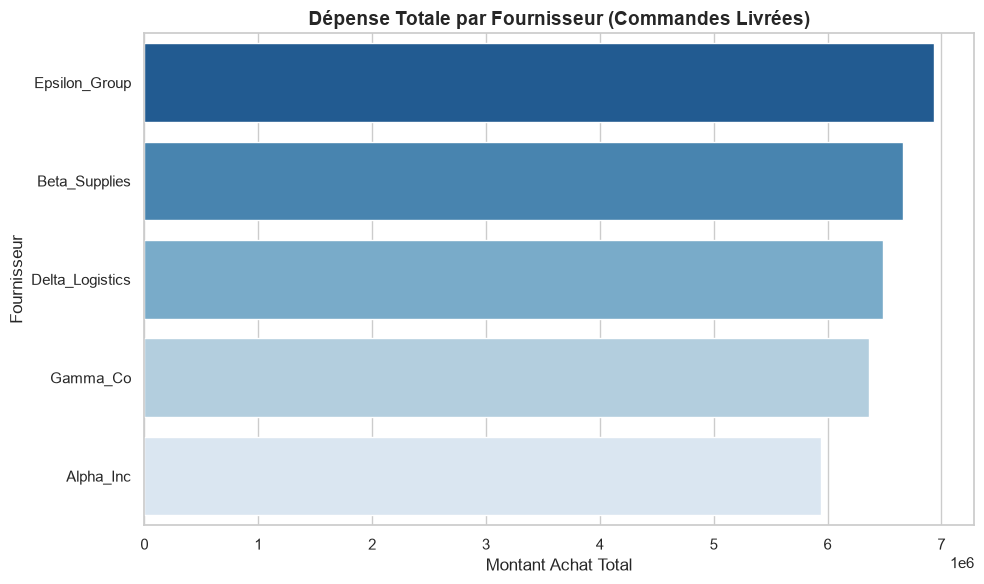

In [126]:
print(df['Supplier'].value_counts())
print(df['Supplier'].unique())

condition = df['Order_Status']== 'Delivered'
df_deliverd = df[condition].copy()
Spend_supplier = df_deliverd.groupby('Supplier')['Total_Spend'].sum().sort_values(ascending=False)
df_deliverd['Savings_per_Order'] = df_deliverd['Expected_Spend'] - df_deliverd['Total_Spend']
print(Spend_supplier)
for i,(nom,val),in enumerate(Spend_supplier.items(),1):
    pourcentage = (val/df['Total_Spend'].sum())*100
    print(f" Numéro {i}, fournisseur : {nom:<9}, montant d'achat : {val:.2f}, pourcentage {pourcentage:.2f}%")


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    x=Spend_supplier.values, y=Spend_supplier.index, palette='Blues_r'
)

plt.title(
    'Dépense Totale par Fournisseur (Commandes Livrées)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel("Montant Achat Total", fontsize=12)
plt.ylabel('Fournisseur', fontsize=12)

plt.tight_layout()
plt.show()

203    35.714286
201    18.726592
677    18.660287
391    18.316832
595    18.214286
         ...    
68      0.000000
731     0.000000
750     0.000000
752     0.000000
0       0.000000
Name: Defect_Rate, Length: 776, dtype: float64
Supplier
Delta_Logistics    10.866574
Beta_Supplies       8.272327
Gamma_Co            4.497537
Epsilon_Group       2.606269
Alpha_Inc           1.897281
Name: Defect_Rate, dtype: float64
Numéro 1  | nom de fournisseur : Delta_Logistics | taux de defectueux:10.87%
Numéro 2  | nom de fournisseur : Beta_Supplies   | taux de defectueux:8.27%
Numéro 3  | nom de fournisseur : Gamma_Co        | taux de defectueux:4.50%
Numéro 4  | nom de fournisseur : Epsilon_Group   | taux de defectueux:2.61%
Numéro 5  | nom de fournisseur : Alpha_Inc       | taux de defectueux:1.90%


C:\Users\lilig\AppData\Local\Temp\ipykernel_17448\1948795682.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


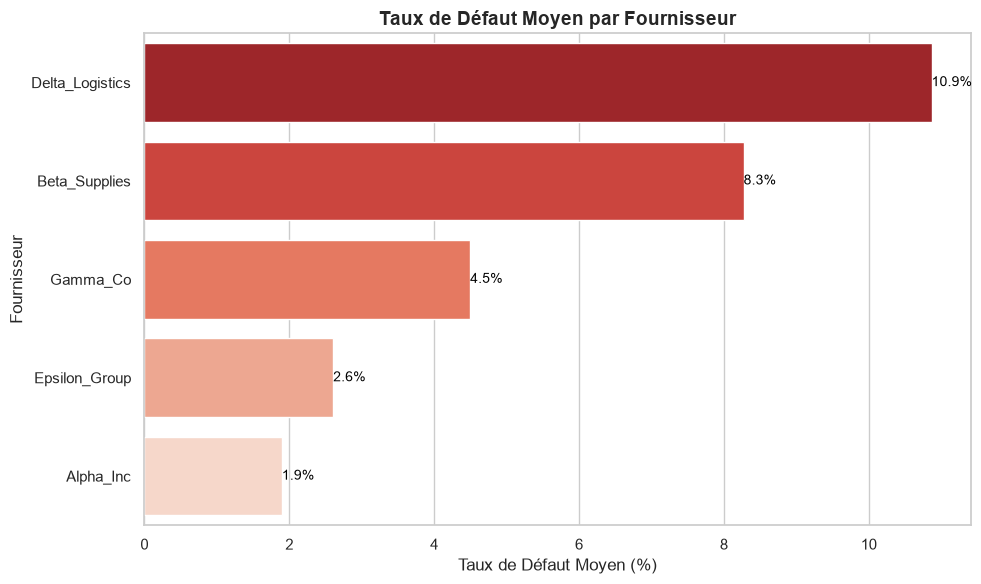

In [132]:
#-----Supplier Performance---------

print(df['Defect_Rate'].sort_values(ascending=False))
Defect_Rate_Supplier = df.groupby('Supplier')['Defect_Rate'].mean().sort_values(ascending=False)
print(Defect_Rate_Supplier)
for i,(nom,taux) in enumerate(Defect_Rate_Supplier.items(),1):
    print(f"Numéro {i}  | nom de fournisseur : {nom:<15} | taux de defectueux:{taux:.2f}%")

sns.set_theme(style="whitegrid")
fig_height = max(6, len(Defect_Rate_Supplier) * 0.3)
plt.figure(figsize=(10, fig_height))
sns.barplot(
    x=Defect_Rate_Supplier.values,
    y=Defect_Rate_Supplier.index,
    palette="Reds_r"
)
plt.title(
    "Taux de Défaut Moyen par Fournisseur",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Taux de Défaut Moyen (%)", fontsize=12)
plt.ylabel("Fournisseur", fontsize=12)
for index, value in enumerate(Defect_Rate_Supplier.values):
    plt.text(value, index, f'{value:.1f}%', color='black', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [128]:
#Lead_Time_Performance
print(df['Lead_time'])
temps_livraison_moyenne = round(df_deliverd['Lead_time'].mean(),2)
print(temps_livraison_moyenne)
Lead_Time_Performa = df_deliverd.groupby('Supplier')['Lead_time'].mean().sort_values(ascending=False)
print(Lead_Time_Performa )
for i,(nom,jours) in enumerate(Lead_Time_Performa.items()):
    if jours > temps_livraison_moyenne:
        print(f" Temps de livraison en moyenne de {nom} est supérieur que la moyenne :{temps_livraison_moyenne} jours")

0       8.0
1      10.0
2      20.0
3      19.0
4      12.0
       ... 
772     9.0
773     NaN
774    19.0
775    12.0
776     2.0
Name: Lead_time, Length: 776, dtype: float64
10.52
Supplier
Beta_Supplies      11.230000
Alpha_Inc          10.715909
Epsilon_Group      10.485981
Delta_Logistics    10.271845
Gamma_Co            9.903226
Name: Lead_time, dtype: float64
 Temps de livraison en moyenne de Beta_Supplies est supérieur que la moyenne :10.52 jours
 Temps de livraison en moyenne de Alpha_Inc est supérieur que la moyenne :10.52 jours


In [129]:
#-----Operational Efficiency---------
supplier_summary = df_deliverd.groupby('Supplier').agg(
    {'Total_Spend': 'sum','Defect_Rate':'mean','Lead_time':'mean','Savings_per_Order': 'sum'}
    ).sort_values(by='Savings_per_Order',ascending=False)
print(supplier_summary)

                 Total_Spend  Defect_Rate  Lead_time  Savings_per_Order
Supplier                                                               
Beta_Supplies     6659805.99     8.200564  11.230000          583440.95
Epsilon_Group     6939305.77     2.629524  10.485981          577220.17
Gamma_Co          6366208.96     4.528057   9.903226          552366.47
Delta_Logistics   6486281.80    10.374381  10.271845          533389.96
Alpha_Inc         5943260.90     1.965528  10.715909          511757.46


                 Lead_time           Defect_Rate Compliance
                      mean       std        mean   <lambda>
Supplier                                                   
Gamma_Co          9.903226  5.379236    4.528057  86.407767
Epsilon_Group    10.485981  5.610577    2.629524  98.333333
Alpha_Inc        10.715909  5.622101    1.965528  93.396226
Beta_Supplies    11.230000  5.981208    8.200564  75.454545
Delta_Logistics  10.271845  6.091129   10.374381  61.666667


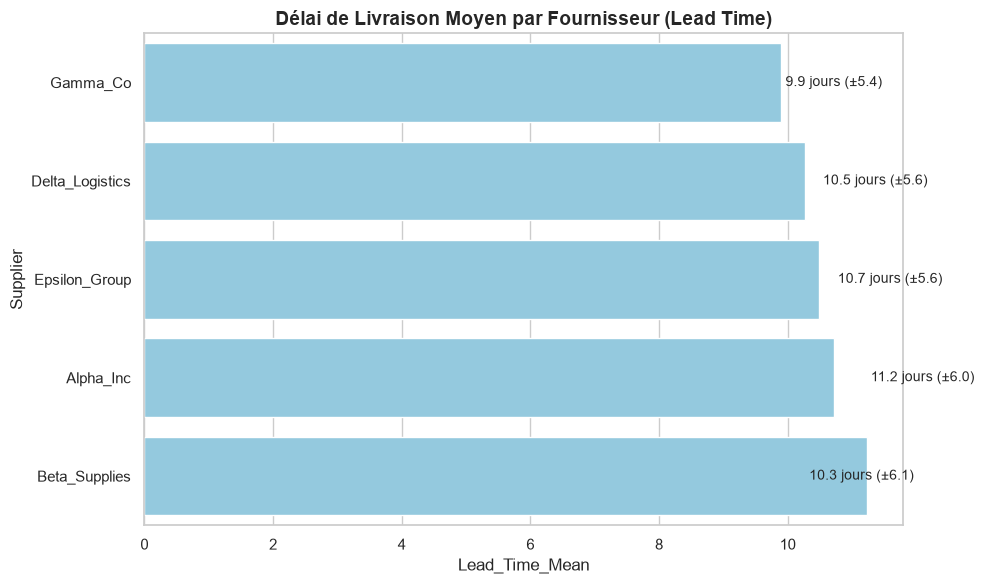

Text(0, 0.5, 'Fournisseur')

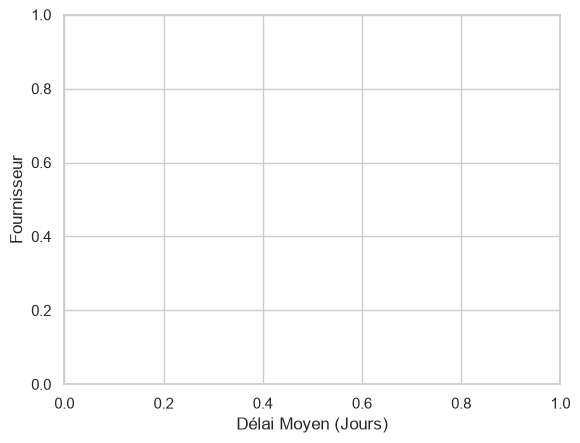

In [133]:
#-----Operational Efficiency---------

efficiency_summary = df_deliverd.groupby('Supplier').agg({
    'Lead_time': ['mean', 'std'],  
    'Defect_Rate': 'mean',
    'Compliance': lambda x: (x == 'Yes').mean() * 100 
}).sort_values(by=('Lead_time', 'std'), ascending=True)

print(efficiency_summary)

df_plot = efficiency_summary.copy()
df_plot.columns = ['Lead_Time_Mean', 'Lead_Time_Std', 'Defect_Rate_Mean', 'Compliance_Rate']
df_plot = df_plot.reset_index()
df_plot = df_plot.sort_values(by='Lead_Time_Mean', ascending=True)
fig_height = max(6, len(df_plot) * 0.3)
plt.figure(figsize=(10, fig_height))
sns.barplot(
    data=df_plot,
    x='Lead_Time_Mean',
    y='Supplier',
    color='skyblue'
)
plt.title(
    "Délai de Livraison Moyen par Fournisseur (Lead Time)",
    fontsize=14,
    fontweight="bold"
)
for index, row in df_plot.iterrows():
    plt.text(
        row['Lead_Time_Mean'], 
        index, 
        f" {row['Lead_Time_Mean']:.1f} jours (±{row['Lead_Time_Std']:.1f})", 
        va='center', 
        fontsize=10
    )

plt.tight_layout()
plt.show()
plt.xlabel("Délai Moyen (Jours)", fontsize=12)
plt.ylabel("Fournisseur", fontsize=12)